In [1]:
import os
from pathlib import Path
from utils import data_loader_utils
from utils import user_defined_functions as udf
import itertools 
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab

import pandas as pd
import math

from scipy import ndimage
from scipy.stats import pearsonr
import scipy.signal as signal

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
machines = ["M01","M02","M03"]
#process_names = ["OP00","OP01","OP02","OP03","OP04","OP05","OP06","OP07","OP08","OP09","OP10","OP11","OP12","OP13","OP14"]
process_names = ["OP07"]
labels_good = ["good"]
labels_bad = ["bad"]
path_to_dataset = Path("./data/").absolute()

In [3]:
data_good = []
label_data_good = []

for process_name, machine, label in itertools.product(process_names, machines, labels_good):
    data_path = os.path.join(path_to_dataset, machine, process_name, label)
    data_list, data_label = data_loader_utils.load_tool_research_data(data_path, label=label)
    #concatenating
    data_good.extend(data_list)
    label_data_good.extend(data_label)

loading files from C:\Users\20223628\OneDrive - TU Eindhoven\Documents\Stochastics\5SC29-Group-4-Project\data\M01\OP07\good... 
loading files from C:\Users\20223628\OneDrive - TU Eindhoven\Documents\Stochastics\5SC29-Group-4-Project\data\M02\OP07\good... 
loading files from C:\Users\20223628\OneDrive - TU Eindhoven\Documents\Stochastics\5SC29-Group-4-Project\data\M03\OP07\good... 


In [4]:
data_bad = []
label_data_bad = []

for process_name, machine, label in itertools.product(process_names, machines, labels_bad):
    data_path = os.path.join(path_to_dataset, machine, process_name, label)
    data_list, data_label = data_loader_utils.load_tool_research_data(data_path, label=label)
    #concatenating
    data_bad.extend(data_list)
    label_data_bad.extend(data_label)

loading files from C:\Users\20223628\OneDrive - TU Eindhoven\Documents\Stochastics\5SC29-Group-4-Project\data\M01\OP07\bad... 
loading files from C:\Users\20223628\OneDrive - TU Eindhoven\Documents\Stochastics\5SC29-Group-4-Project\data\M02\OP07\bad... 
loading files from C:\Users\20223628\OneDrive - TU Eindhoven\Documents\Stochastics\5SC29-Group-4-Project\data\M03\OP07\bad... 


In [5]:
features_data_tree = []
labels_tree = []
end_value = 15000
for i in range(len(data_good)):
    features = udf.extract_features(data_good[i][:end_value,0], data_good[i][:end_value,1], data_good[i][:end_value,2])
    features_data_tree.append(features)
    labels_tree.append(1)
for i in range(len(data_bad)):
    features = udf.extract_features(data_bad[i][:end_value,0], data_bad[i][:end_value,1], data_bad[i][:end_value,2])
    features_data_tree.append(features)
    labels_tree.append(0)
features_data_array = np.array(features_data_tree)
features_data_tree = pd.DataFrame(features_data_tree)

In [6]:
y_target_tree = np.array(labels_tree)
X_train, X_test, y_train, y_test = train_test_split(features_data_tree, y_target_tree, test_size=0.3, random_state=42)

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5,        # Keep trees shallow to avoid memorizing noise
    random_state=42,
    n_jobs=-1           # Use all CPU cores
)
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# --- 5. Evaluation ---
preds = rf_model.predict(X_test)
acc = accuracy_score(y_test, preds)

print("-" * 30)
print(f"Random Forest Accuracy: {acc * 100:.2f}%")
print("-" * 30)

print("Feature Importances:")
# This tells you which physical characteristic actually flagged the fault
importances = pd.Series(rf_model.feature_importances_, index=features_data_tree.columns).sort_values(ascending=False)
print(importances)

print("\nConfusion Matrix (True Neg, False Pos, False Neg, True Pos):")
print(confusion_matrix(y_test, preds))

Training Random Forest...
------------------------------
Random Forest Accuracy: 100.00%
------------------------------
Feature Importances:
x_psd_rms                 0.254646
x_psd_max                 0.204082
z_psd_max                 0.152424
y_psd_rms                 0.138345
y_psd_max                 0.100000
max_cross_corr_xy         0.084756
z_psd_rms                 0.052157
cross_corr_xy_kurtosis    0.013591
dtype: float64

Confusion Matrix (True Neg, False Pos, False Neg, True Pos):
[[ 4  0]
 [ 0 44]]


In [8]:
features_data_tree_mean_std = features_data_tree
features_data_tree_mean_std['label'] = labels_tree

stats_per_class = features_data_tree.groupby('label').agg(['mean', 'std'])
print(stats_per_class)

      max_cross_corr_xy               cross_corr_xy_kurtosis            \
                   mean           std                   mean       std   
label                                                                    
0          5.492317e+08  2.959200e+08               7.981802  3.018631   
1          1.056635e+08  4.390976e+07               4.067876  1.334028   

        x_psd_rms               y_psd_rms               z_psd_rms              \
             mean         std        mean         std        mean         std   
label                                                                           
0      963.406834  103.437563  333.714114  163.322356  341.974615  304.406413   
1      632.169310   47.006100   58.571793   18.560361   28.698540   11.949751   

          x_psd_max                   y_psd_max                   z_psd_max  \
               mean           std          mean           std          mean   
label                                                            

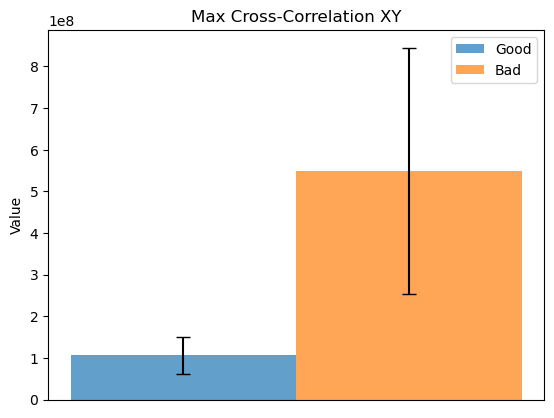

In [9]:
grouped = features_data_tree.groupby('label')

mean_per_class = grouped.mean()
std_per_class  = grouped.std()

mean_good = mean_per_class.loc[1]
mean_bad  = mean_per_class.loc[0]

std_good = std_per_class.loc[1]
std_bad  = std_per_class.loc[0]

plt.figure()
labels = ['Good', 'Bad']
means = [mean_good['max_cross_corr_xy'], mean_bad['max_cross_corr_xy']]
stds  = [std_good['max_cross_corr_xy'],  std_bad['max_cross_corr_xy']]

width = 0.35
x = 1

plt.bar(x - width/2, mean_good['max_cross_corr_xy'], width, yerr=std_good['max_cross_corr_xy'], capsize=5, alpha=0.7, label='Good')
plt.bar(x + width/2, mean_bad['max_cross_corr_xy'],  width, yerr=std_bad['max_cross_corr_xy'],  capsize=5, alpha=0.7, label='Bad')
#plt.bar(x, means, yerr=stds, capsize=5, alpha=0.7)
#plt.xticks(x, labels)
plt.ylabel('Value')
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
plt.title('Max Cross-Correlation XY')
plt.legend()
plt.show()

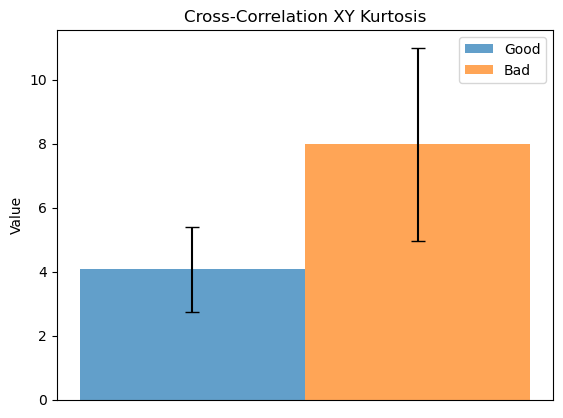

In [10]:
plt.figure()
means = [mean_good['cross_corr_xy_kurtosis'], mean_bad['cross_corr_xy_kurtosis']]
stds  = [std_good['cross_corr_xy_kurtosis'],  std_bad['cross_corr_xy_kurtosis']]
x = 1

width = 0.35

plt.bar(x - width/2, mean_good['cross_corr_xy_kurtosis'], width, yerr=std_good['cross_corr_xy_kurtosis'], capsize=5, alpha=0.7, label='Good')
plt.bar(x + width/2, mean_bad['cross_corr_xy_kurtosis'],  width, yerr=std_bad['cross_corr_xy_kurtosis'],  capsize=5, alpha=0.7, label='Bad')
#plt.bar(x, means, yerr=stds, capsize=5, alpha=0.7)
#plt.xticks(x, labels)
plt.ylabel('Value')
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
plt.title('Cross-Correlation XY Kurtosis')
plt.legend()
plt.show()

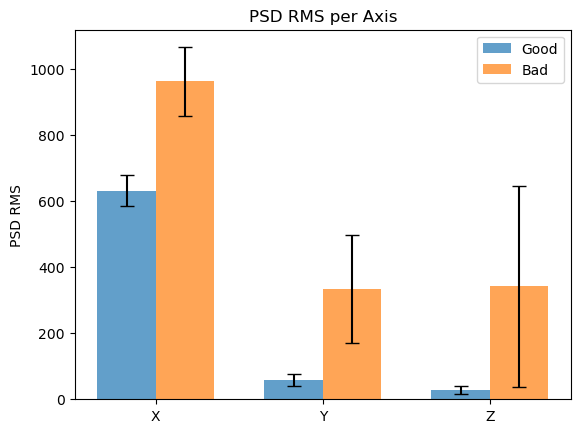

In [11]:
plt.figure()

axes = ['x', 'y', 'z']
features = [f'{a}_psd_rms' for a in axes]

means_good = [mean_good[f] for f in features]
means_bad  = [mean_bad[f]  for f in features]

stds_good = [std_good[f] for f in features]
stds_bad  = [std_bad[f]  for f in features]

x = np.arange(len(axes))
width = 0.35

plt.bar(x - width/2, means_good, width, yerr=stds_good, capsize=5, alpha=0.7, label='Good')
plt.bar(x + width/2, means_bad,  width, yerr=stds_bad,  capsize=5, alpha=0.7, label='Bad')

plt.xticks(x, ['X', 'Y', 'Z'])
plt.ylabel('PSD RMS')
plt.title('PSD RMS per Axis')
plt.legend()
plt.show()

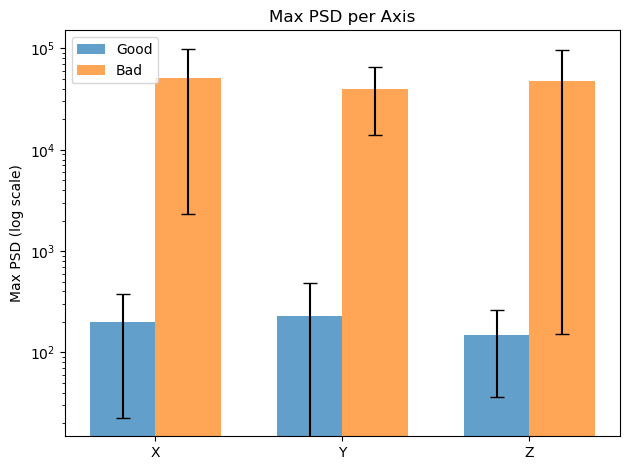

In [12]:
plt.figure()

axes = ['x', 'y', 'z']
features = [f'{a}_psd_max' for a in axes]

means_good = [mean_good[f] for f in features]
means_bad  = [mean_bad[f]  for f in features]

stds_good = [std_good[f] for f in features]
stds_bad  = [std_bad[f]  for f in features]

#means_good = 10*np.log10(means_good)
#means_bad = 10*np.log10(means_bad)
#stds_good = 20*np.log10(stds_good)
#stds_bad = 20*np.log10(stds_bad)

x = np.arange(len(axes))
width = 0.35

plt.bar(
    x - width/2,
    means_good,
    width,
    yerr=stds_good,
    capsize=5,
    alpha=0.7,
    label='Good'
)

plt.bar(
    x + width/2,
    means_bad,
    width,
    yerr=stds_bad,
    capsize=5,
    alpha=0.7,
    label='Bad'
)

plt.yscale('log')   # 🔑 logarithmic y-axis

plt.xticks(x, ['X', 'Y', 'Z'])
plt.ylabel('Max PSD (log scale)')
plt.title('Max PSD per Axis')
plt.legend()
plt.tight_layout()
plt.show()